<a href="https://colab.research.google.com/github/DungeonProgger/IOS-Android/blob/main/Main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Загружаем нормализованный датасет
file_path = "NN_Training_Dataset.csv"
df = pd.read_csv(file_path)

# Выведем размерность данных, чтобы убедиться, что всё загрузилось
print(f"Размер датасета: {df.shape[0]} строк и {df.shape[1]} признаков")

Размер датасета: 41 строк и 51 признаков


In [3]:
# Отделяем целевую переменную (ответ) от признаков
target_column = '22. У Вас айфон или андроид?'
X = df.drop(target_column, axis=1) # Признаки (вопросы анкеты)
y = df[target_column]              # Целевая переменная (0 - Айфон, 1 - Андроид)

# Разбиваем данные на train (обучение) и test (проверка)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 20% данных откладываем для теста
    random_state=42,  # Фиксируем seed для воспроизводимости результатов
    stratify=y        # Сохраняем пропорции пользователей Айфонов и Андроидов в обеих выборках
)

print(f"Размер обучающей выборки: {X_train.shape[0]} строк")
print(f"Размер тестовой выборки: {X_test.shape[0]} строк")

Размер обучающей выборки: 32 строк
Размер тестовой выборки: 9 строк


In [10]:
# Инициализируем модель K-Nearest Neighbors
# n_neighbors - количество соседей, которое мы учитываем. Обычно берут нечетное число (3, 5, 7).
knn = KNeighborsClassifier(n_neighbors=2)

# Обучаем модель на тренировочных данных
knn.fit(X_train, y_train)

print("Модель успешно обучена!")

Модель успешно обучена!


In [11]:
# Делаем предсказания на тестовой выборке
y_pred = knn.predict(X_test)

# Оцениваем точность
accuracy = accuracy_score(y_test, y_pred)
print(f"Общая точность (Accuracy): {accuracy:.2f}\n")

# Выводим подробный отчет (Precision, Recall, F1-score)
print("Отчет о классификации:")
print(classification_report(y_test, y_pred, target_names=['Айфон (0)', 'Андроид (1)']))

Общая точность (Accuracy): 0.67

Отчет о классификации:
              precision    recall  f1-score   support

   Айфон (0)       0.57      1.00      0.73         4
 Андроид (1)       1.00      0.40      0.57         5

    accuracy                           0.67         9
   macro avg       0.79      0.70      0.65         9
weighted avg       0.81      0.67      0.64         9



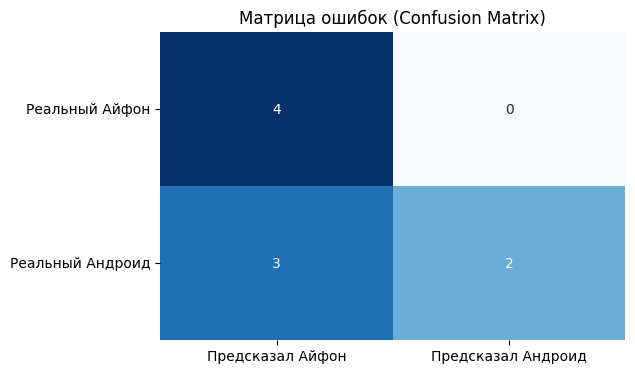

In [12]:
# Строим матрицу ошибок
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Предсказал Айфон', 'Предсказал Андроид'],
            yticklabels=['Реальный Айфон', 'Реальный Андроид'])

plt.title('Матрица ошибок (Confusion Matrix)')
plt.yticks(rotation=0)
plt.show()